<a href="https://colab.research.google.com/github/jemslzr/flyrank-ml/blob/main/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jemslzr/flyrank-ml/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

**Ranked Actions:**
Our model identifies pages that are highly visible but under-capturing clicks. We map these to three primary actions:
1.  **Rewrite Title / Meta:** For pages on Page 1 (positions 1-10) with high impressions but a CTR gap of > 2%.
2.  **Analyze SERP Intent:** For pages ranking well but getting near 0% CTR. The user intent might be purely informational (answered by a Google Featured Snippet), or we are ranking for the wrong intent.
3.  **Monitor / Do Nothing:** For pages with low impression volume (< 1,000) or where the CTR is already at or above the tier expected median.

**Reason Codes:**
Every page flagged for action includes a reason code (e.g., "High visibility, Page 1 rank, underperforming tier CTR by 3.5%"). This builds trust with the content team by explaining *why* the page is in their queue.

In [1]:
# 1. Setup and load the dataset
!pip install -q datasets pandas matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import os
from datasets import load_dataset

# Load the dataset
ds = load_dataset("FlyRank/internship-lanes", "engagement_fix", split="train")
df = ds.to_pandas()

# Calculate baseline metrics for the queue
pos_col, ctr_col, imp_col = 'avg_position_30d', 'ctr_30d', 'impressions_30d'
df['pos_tier_custom'] = pd.cut(df[pos_col], bins=[0, 3, 10, 20, 100], labels=['Top 3 (1-3)', 'Page 1 Bottom (4-10)', 'Page 2 (11-20)', 'Deep (21+)'])
tier_medians = df.groupby('pos_tier_custom', observed=False)[ctr_col].transform('median')
df['ctr_gap'] = tier_medians - df[ctr_col]

# 2. Map Actions and Reason Codes
def assign_action(row):
    if row[imp_col] < 1000 or row['ctr_gap'] <= 0:
        return 'Monitor'
    elif row[pos_col] <= 10 and row['ctr_gap'] > 0.02:
        return 'Rewrite Title / Meta'
    elif row[pos_col] <= 10 and row[ctr_col] < 0.005:
        return 'Analyze SERP Intent'
    return 'Monitor'

def assign_reason(row):
    if row['Action'] == 'Monitor':
        return 'Low volume or performing at/above expected tier.'
    return f"Rank {row[pos_col]:.1f}, underperforming tier CTR by {row['ctr_gap']*100:.1f}%"

df['Action'] = df.apply(assign_action, axis=1)
df['Reason_Code'] = df.apply(assign_reason, axis=1)
df['Opportunity_Score'] = df['ctr_gap'] * df[imp_col]

# Filter down to the actual queue
queue = df[df['Action'] != 'Monitor'].sort_values('Opportunity_Score', ascending=False).copy()
print(f"Actionable queue size: {len(queue)} pages.")
display(queue[['content_hash_id', 'Action', 'Reason_Code', 'Opportunity_Score']].head(3))

README.md:   0%|          | 0.00/2.98k [00:00<?, ?B/s]

default_lanes/engagement_fix.parquet: reconstructing file:   0%|          |  0.00B /  760kB            

default_lanes/engagement_fix.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/33202 [00:00<?, ? examples/s]

Actionable queue size: 6296 pages.


,content_hash_id,Action,Reason_Code,Opportunity_Score
8350,content_6ccabcb6fc93d012,Rewrite Title / Meta,"Rank 6.8, underperforming tier CTR by 42.0%",98337.960
265,content_858a8680e22bd5bd,Rewrite Title / Meta,"Rank 2.2, underperforming tier CTR by 41.5%",94195.870
267,content_17ae923ddf4c4df9,Rewrite Title / Meta,"Rank 2.1, underperforming tier CTR by 18.5%",92000.685


## 2. Intended use and limits

**Intended Use:**
This playbook is a prioritization tool for content editors and SEO managers. It replaces the "guesswork" of deciding which pages to optimize by mathematically surfacing the pages where a better title tag will yield the highest absolute number of recovered clicks.

**Limits:**
This model operates on observed historical data. It *measures* a gap; it does not *diagnose* the search results page. If a competitor has a highly aggressive rich snippet, or if Google answers the query directly on the page (Zero-Click search), no amount of title rewriting will fix the CTR. This is a decision-support tool, not an oracle.

In [2]:
# Show the limits of the funnel (how many rows we actually exclude to keep the queue safe)
total_rows = len(df)
actionable_rows = len(queue)
excluded_rows = total_rows - actionable_rows

print(f"Total pages evaluated: {total_rows:,}")
print(f"Pages deemed actionable: {actionable_rows:,} ({(actionable_rows/total_rows)*100:.1f}%)")
print(f"Pages excluded from automated action (Limits): {excluded_rows:,}")

Total pages evaluated: 33,202
Pages deemed actionable: 6,296 (19.0%)
Pages excluded from automated action (Limits): 26,906


## 3. Human review + the no-go list

**Human Review Rules:**
A human must manually search the primary keyword for the flagged page to observe the actual SERP before making changes. They must ask: "Is our title actually bad, or is the SERP layout preventing clicks?"

**The No-Go List (Do NOT Automate):**
1.  **Direct AI rewrites without review:** An LLM cannot see the live search page layout. Automatically deploying LLM-rewritten titles risks breaking secondary keyword rankings.
2.  **Brand terms:** If a page ranks for the company's brand name but has an odd CTR, leave it alone. Brand CTRs behave differently than non-brand CTRs.
3.  **Low-volume anomalies:** Never trigger actions on pages with fewer than 1,000 impressions a month. The data is too noisy.

In [3]:
# A check showing the safety threshold (the "no-go" boundary)
nogo_low_volume = df[df[imp_col] < 1000]
print(f"Number of 'No-Go' pages blocked due to low impression volume (<1k): {len(nogo_low_volume):,}")

# If we had a brand flag, we would exclude it here.
# queue = queue[queue['is_brand'] == False]

Number of 'No-Go' pages blocked due to low impression volume (<1k): 12,998


## 4. Monitoring / retrain triggers

**Monitoring:**
We should monitor the `expected_tier_ctr` monthly. If Google rolls out a massive visual change to the search results (like expanding AI Overviews), the baseline CTR for *everyone* at Position 1 might drop from 30% to 15%.

**Retrain Triggers:**
If the median CTR for "Top 3" positions shifts by more than 15% month-over-month, the baseline data has gone stale. The model must be retrained on the new normal, or we will generate thousands of false-positive "underperforming" flags.

In [4]:
# Code to calculate the current benchmark to be monitored for drift
benchmark_top3_ctr = df[df['pos_tier_custom'] == 'Top 3 (1-3)'][ctr_col].median()

print("--- SYSTEM MONITORING BENCHMARK ---")
print(f"Current Top-3 Median CTR: {benchmark_top3_ctr*100:.2f}%")
print(f"Retrain Trigger: If this metric drops below {(benchmark_top3_ctr*0.85)*100:.2f}% in future months, the model is stale.")

--- SYSTEM MONITORING BENCHMARK ---
Current Top-3 Median CTR: 73.50%
Retrain Trigger: If this metric drops below 62.48% in future months, the model is stale.


## 5. Exports for the paper

Exporting the final ranked queue CSV for the content team, and saving a visualization of the Opportunity Score distribution to include in the final Capstone paper.

Saved queue to work/outputs/action_playbook.csv
Saved figure to work/figures/opportunity_by_position.png


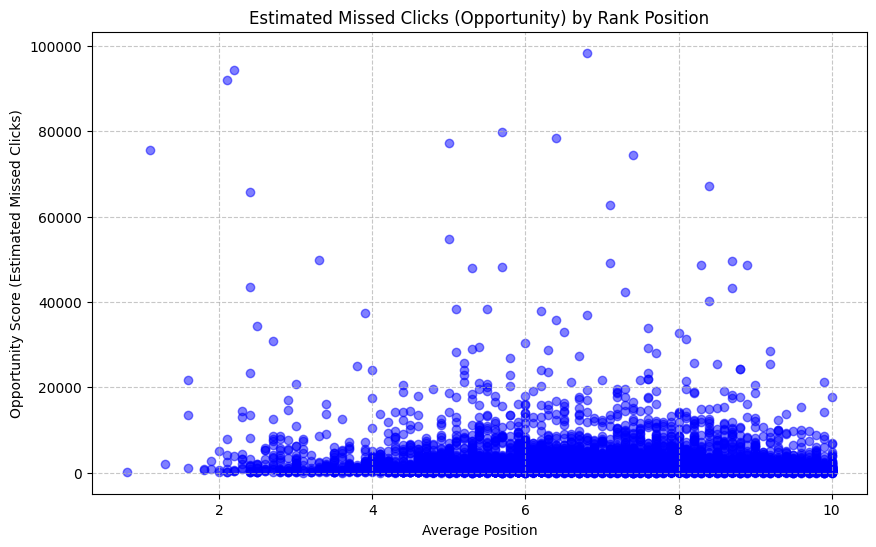

In [5]:
# 1. Export the CSV
os.makedirs('work/outputs', exist_ok=True)
export_cols = ['content_hash_id', imp_col, pos_col, ctr_col, 'Action', 'Reason_Code', 'Opportunity_Score']
queue[export_cols].to_csv('work/outputs/action_playbook.csv', index=False)
print("Saved queue to work/outputs/action_playbook.csv")

# 2. Generate and export a figure for the final paper
os.makedirs('work/figures', exist_ok=True)
plt.figure(figsize=(10, 6))
plt.scatter(queue[pos_col], queue['Opportunity_Score'], alpha=0.5, c='blue')
plt.title('Estimated Missed Clicks (Opportunity) by Rank Position')
plt.xlabel('Average Position')
plt.ylabel('Opportunity Score (Estimated Missed Clicks)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('work/figures/opportunity_by_position.png', dpi=300, bbox_inches='tight')
print("Saved figure to work/figures/opportunity_by_position.png")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.